# pyMotorGeo v1.6 — 상용 서비스 시연

DXF 파일 → 모터 기하 자동 분석 → 영역 명명 → pyleecan 변환까지 전 과정을 시연합니다.

**워크플로우**
```
DXF 입력
  └─[1] 파싱·에어갭 탐지·Stator/Rotor 분리
  └─[2] 극수·슬롯수 추정
  └─[3] 1극/1슬롯 경계 닫기 (shapely polygonize)
  └─[4] 닫힌 face 탐지 + 자동 이름 부여
  └─[5] 대화형 영역 GUI (수정 가능)
  └─[6] JSON / pyleecan 내보내기
```

## Cell 1 — 환경 설정

In [2]:
import sys, importlib

# ─── 경로 설정 ────────────────────────────────────────────────
PKG_DIR = r"D:\KangDH\Emlab_emach\Class"
DXF_PATH = r"E:\KDH\AdaptiveTemplate\TestCAD1.dxf"
JSON_OUT  = r"D:\KangDH\Emlab_emach\mlxperPJT\result_demo.json"

if PKG_DIR not in sys.path:
    sys.path.insert(0, PKG_DIR)

# ─── 패키지 import (재로드) ───────────────────────────────────
import pyMotorGeo
import pyMotorGeo.core, pyMotorGeo.reader, pyMotorGeo.pipeline
import pyMotorGeo.analysis_airgap, pyMotorGeo.analysis_rotor
import pyMotorGeo.analysis_stator
import pyMotorGeo.half_unit, pyMotorGeo.region_closing
import pyMotorGeo.face_detection
import pyMotorGeo.topology_rotor, pyMotorGeo.topology_stator
import pyMotorGeo.pyleecan_bridge
import pyMotorGeo.gui_region, pyMotorGeo.plotting

for _mod in [
    pyMotorGeo.core, pyMotorGeo.reader, pyMotorGeo.pipeline,
    pyMotorGeo.analysis_airgap, pyMotorGeo.analysis_rotor,
    pyMotorGeo.analysis_stator,
    pyMotorGeo.half_unit, pyMotorGeo.region_closing,
    pyMotorGeo.face_detection,
    pyMotorGeo.topology_rotor, pyMotorGeo.topology_stator,
    pyMotorGeo.pyleecan_bridge,
    pyMotorGeo.gui_region, pyMotorGeo.plotting,
    pyMotorGeo,
]:
    importlib.reload(_mod)

from pyMotorGeo import (
    analyze_dxf_v2, export_result_json,
    detect_closed_faces_v2, auto_name_faces_v2,
    FaceRegionGUI, FaceRegionGUILite,
    plot_faces_static,
    build_machine_from_faces,
)

print(f"pyMotorGeo v{pyMotorGeo.__version__}  |  DXF: {DXF_PATH}")

pyMotorGeo v1.5.1  |  DXF: E:\KDH\AdaptiveTemplate\TestCAD1.dxf


## Cell 2 — 한 줄 분석 (`analyze_dxf_v2`)

8단계 파이프라인을 한 번에 실행합니다.
- 극수·슬롯수를 아는 경우 `n_poles=8, n_slots=48` 처럼 직접 지정하면 더 빠릅니다.

In [13]:
result = analyze_dxf_v2(
    DXF_PATH,
    origin=(0.0, 0.0),
    n_poles=8,   # 자동 추정 시 주석 처리
    n_slots=48,  # 자동 추정 시 주석 처리
    enable_radius_fallback=True,
    fallback_r_shaft_mm=23.0,
    fallback_r_stator_outer_mm=99.0,
    verbose=True,
)


  pyMotorGeo v1.5.1 — DXF 분석
  파일: E:\KDH\AdaptiveTemplate\TestCAD1.dxf
[1/8] DXF 파싱 중...
[read_entity_list] 2208 entities loaded from E:\KDH\AdaptiveTemplate\TestCAD1.dxf
  Entity types: {'ARC': 560, 'LINE': 1648}
  _MotorCAD0_                     1
  _MotorCAD1_                     1
  _MotorCAD2_                     1
  _MotorCAD3_                     1
  _MotorCAD4_                     1
  _MotorCAD5_                     1
  _MotorCAD6_                     1
  _MotorCAD7_                     1
  _MotorCAD8_                     1
  _MotorCAD9_                     1
      엔티티 2208개 로드
[2/8] 에어갭 탐지 중...
      에어갭: 70.270 mm (inner) / 71.270 mm (outer)
[3/8] Stator / Rotor 분리 중...
[classify] radial LINE count: 752
[classify] slot walls: inner_avg=75.6, outer_avg=79.0, slot_center=77.3
[classify] model radius range: [23.5, 99.0], mid=61.2
[classify] → slot center OUTER → inner_rotor
      [fallback] split: Rotor 136개 / Stator 2200개
      Rotor 136개 / Stator 2200개
[4/8] 극수 / 슬롯수 추정 중...

## Cell 3 — 결과 요약

In [15]:
dims = result['dims']

print("╔══════════════════════════════════════════════╗")
print("║          모터 기하 분석 결과 요약             ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  토폴로지          : {dims['topology']:<24s}║")
print(f"║  극수 / 슬롯수     : {dims['n_poles']}P / {dims['n_slots']}S{'':<16s}║")
print(f"║  극 피치           : {dims['pole_pitch_deg']:.3f}°{'':<21s}║")
print("╠══════════════════════════════════════════════╣")
print(f"║  샤프트 반경       : {dims['r_shaft_mm']:.3f} mm{'':<18s}║")
print(f"║  로터 외경         : {dims['r_rotor_outer_mm']:.3f} mm{'':<18s}║")
print(f"║  스테이터 내경     : {dims['r_stator_inner_mm']:.3f} mm{'':<18s}║")
print(f"║  스테이터 외경     : {dims['r_stator_outer_mm']:.3f} mm{'':<18s}║")
print(f"║  에어갭            : {dims['airgap_mm']:.3f} mm{'':<18s}║")
print("╠══════════════════════════════════════════════╣")
print(f"║  자석 그룹         : {dims['n_magnet_groups']:<24d}║")
print(f"║  플럭스 배리어     : {dims['n_barriers']:<24d}║")
print(f"║  로터 face 수      : {dims['n_rotor_faces']:<24d}║")
print(f"║  스테이터 face 수  : {dims['n_stator_faces']:<24d}║")
print("╚══════════════════════════════════════════════╝")

# 로터 토폴로지 상세
topo = result.get('rotor_topo', {})
if topo:
    print(f"\n  로터 상세: {topo.get('detail', '')}")

╔══════════════════════════════════════════════╗
║          모터 기하 분석 결과 요약             ║
╠══════════════════════════════════════════════╣
║  토폴로지          : SynRM                   ║
║  극수 / 슬롯수     : 8P / 48S                ║
║  극 피치           : 45.000°                     ║
╠══════════════════════════════════════════════╣
║  샤프트 반경       : 23.455 mm                  ║
║  로터 외경         : 70.270 mm                  ║
║  스테이터 내경     : 71.270 mm                  ║
║  스테이터 외경     : 99.000 mm                  ║
║  에어갭            : 1.000 mm                  ║
╠══════════════════════════════════════════════╣
║  자석 그룹         : 0                       ║
║  플럭스 배리어     : 8                       ║
║  로터 face 수      : 1                       ║
║  스테이터 face 수  : 6                       ║
╚══════════════════════════════════════════════╝

  로터 상세: Synchronous Reluctance (8 flux barriers)


## Cell 4 — 시각화

1극·1슬롯의 닫힌 face를 색상으로 표시합니다.

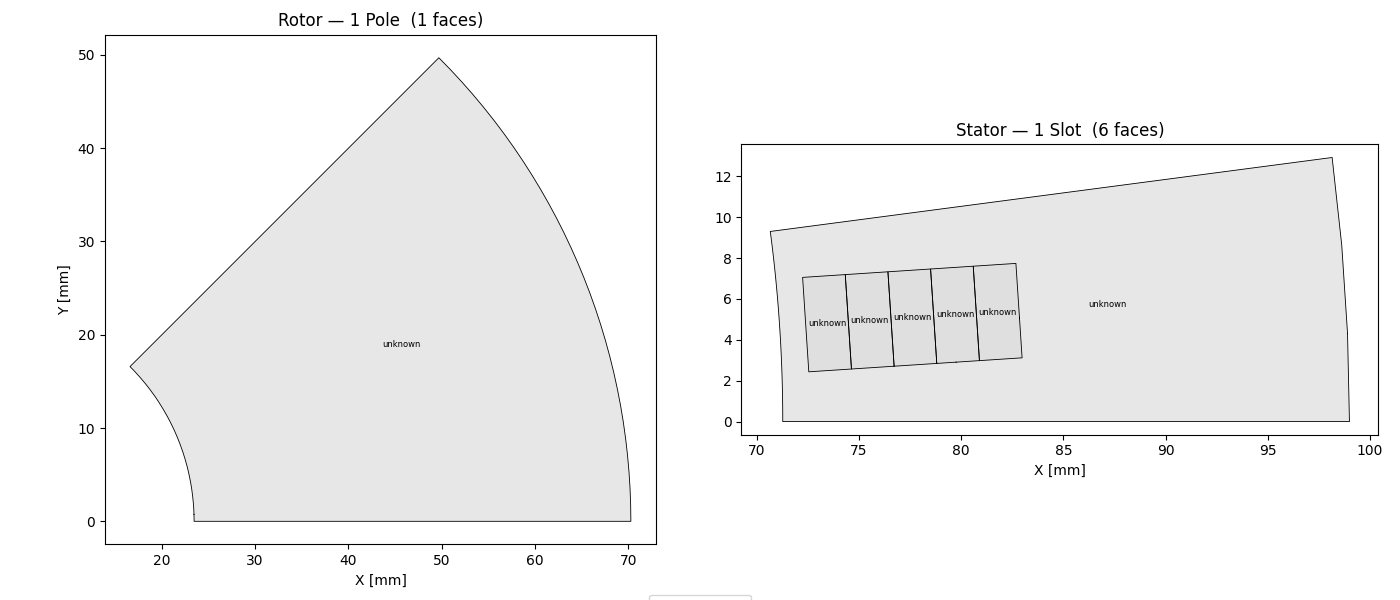

시각화 저장: result_faces.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── 로터 (1극) ──────────────────────────────────────────────
ax = axes[0]
ax.set_aspect('equal')
ax.set_title(f"Rotor — 1 Pole  ({dims['n_rotor_faces']} faces)", fontsize=12)
ax.set_xlabel("X [mm]"); ax.set_ylabel("Y [mm]")

COLOR_MAP = {
    'magnet':       '#FF4444',
    'air_barrier':  '#AADDFF',
    'rotor_core':   '#FFA040',
    'shaft':        '#888888',
    'unknown':      '#DDDDDD',
    'slot_winding': '#44CC88',
    'stator_core':  '#4488FF',
    'stator_back':  '#224488',
    'slot_opening': '#FFFF88',
}

for face in result.get('rotor_faces', []):
    verts = face.get('vertices', [])
    if len(verts) < 3:
        continue
    xs = [p[0] for p in verts] + [verts[0][0]]
    ys = [p[1] for p in verts] + [verts[0][1]]
    region = face.get('region_name', 'unknown')
    color  = COLOR_MAP.get(region, '#DDDDDD')
    ax.fill(xs, ys, color=color, alpha=0.70, linewidth=0)
    ax.plot(xs, ys, 'k-', linewidth=0.6)
    cx, cy = face.get('centroid', (np.mean(xs[:-1]), np.mean(ys[:-1])))
    ax.text(cx, cy, region, fontsize=6, ha='center', va='center')

# ── 스테이터 (1슬롯) ──────────────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.set_title(f"Stator — 1 Slot  ({dims['n_stator_faces']} faces)", fontsize=12)
ax2.set_xlabel("X [mm]")

for face in result.get('stator_faces', []):
    verts = face.get('vertices', [])
    if len(verts) < 3:
        continue
    xs = [p[0] for p in verts] + [verts[0][0]]
    ys = [p[1] for p in verts] + [verts[0][1]]
    region = face.get('region_name', 'unknown')
    color  = COLOR_MAP.get(region, '#DDDDDD')
    ax2.fill(xs, ys, color=color, alpha=0.70, linewidth=0)
    ax2.plot(xs, ys, 'k-', linewidth=0.6)
    cx, cy = face.get('centroid', (np.mean(xs[:-1]), np.mean(ys[:-1])))
    ax2.text(cx, cy, region, fontsize=6, ha='center', va='center')

# 범례
used_regions = set(
    f.get('region_name', 'unknown')
    for f in result.get('rotor_faces', []) + result.get('stator_faces', [])
)
handles = [
    mpatches.Patch(color=COLOR_MAP.get(r, '#DDD'), label=r)
    for r in sorted(used_regions)
]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("result_faces.png", dpi=150, bbox_inches='tight')
plt.show()
print("시각화 저장: result_faces.png")

## Cell 5 — 대화형 영역 GUI

자동 분류 결과를 수정할 수 있습니다.  
- 슬라이더로 face를 선택하고 드롭다운으로 영역 이름을 변경하세요.  
- `result['rotor_faces']` 또는 `result['stator_faces']` 둘 중 하나를 전달합니다.

인터랙티브 영역 할당 (1개 face)
• 클릭: face 선택
• n/p: 다음/이전 face
• 숫자키 1-9: 영역 할당
    1: Stator Yoke
    2: Stator Tooth
    3: Slot
    4: Slot Opening
    5: Airgap
    6: Rotor Core
    7: Magnet
    8: Air Barrier
    9: Shaft


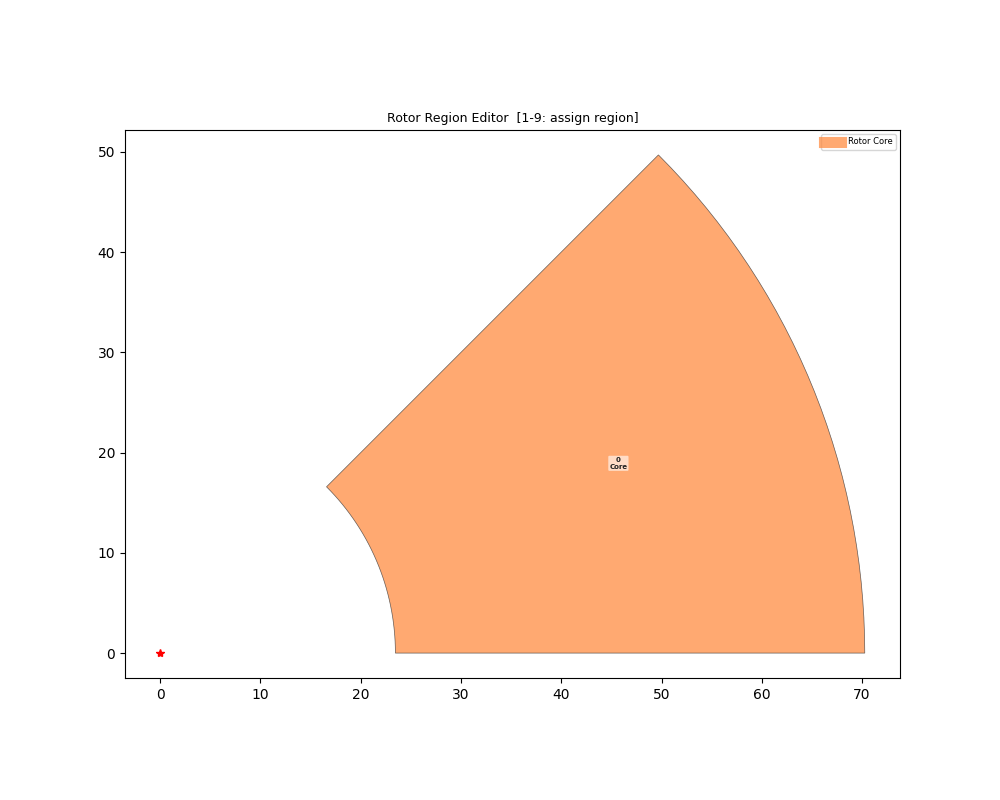

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Rotor Region Editor  [1-9: assign region]'}>)

In [17]:
%matplotlib widget

from pyMotorGeo.region_closing import REGION_NAMES, REGION_COLORS

origin = tuple(result.get('origin', (0.0, 0.0)))
# 로터 영역 GUI
gui_rotor = FaceRegionGUILite(
    faces=result['rotor_faces'],
    origin=origin,
    region_names=REGION_NAMES,
    region_colors=REGION_COLORS,
    title="Rotor Region Editor",
)
gui_rotor.show()

인터랙티브 영역 할당 (6개 face)
• 클릭: face 선택
• n/p: 다음/이전 face
• 숫자키 1-9: 영역 할당
    1: Stator Yoke
    2: Stator Tooth
    3: Slot
    4: Slot Opening
    5: Airgap
    6: Rotor Core
    7: Magnet
    8: Air Barrier
    9: Shaft


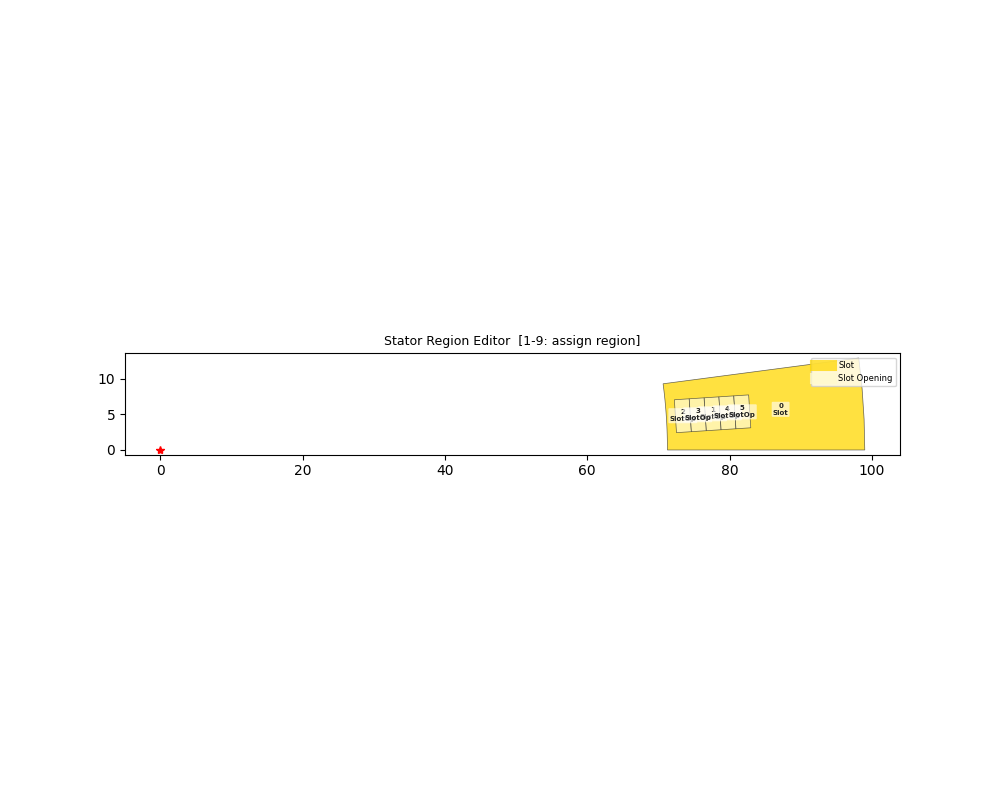

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Stator Region Editor  [1-9: assign region]'}>)

In [7]:
# 스테이터 영역 GUI (필요 시 실행)
from pyMotorGeo.region_closing import REGION_NAMES, REGION_COLORS

origin = tuple(result.get('origin', (0.0, 0.0)))
gui_stator = FaceRegionGUILite(
    faces=result['stator_faces'],
    origin=origin,
    region_names=REGION_NAMES,
    region_colors=REGION_COLORS,
    title="Stator Region Editor",
)
gui_stator.show()

## Cell 6 — 내보내기

### 6-A. JSON 저장

In [8]:
export_result_json(result, JSON_OUT)

# 내용 확인
import json
with open(JSON_OUT, encoding='utf-8') as f:
    saved = json.load(f)

print("저장된 키:", list(saved.keys()))
print("\n[dims]")
for k, v in saved['dims'].items():
    print(f"  {k:<24s}: {v}")
print(f"\n로터 face {len(saved['rotor_faces'])}개  |  스테이터 face {len(saved['stator_faces'])}개")

[export] JSON 저장 완료: D:\KangDH\Emlab_emach\mlxperPJT\result_demo.json
저장된 키: ['dxf_path', 'origin', 'dims', 'rotor_faces', 'stator_faces']

[dims]
  n_poles                 : 8
  n_slots                 : 48
  pole_pitch_deg          : 45.0
  slot_pitch_deg          : 7.5
  r_shaft_mm              : 23.455
  r_rotor_outer_mm        : 70.27
  r_stator_inner_mm       : 71.27
  r_stator_outer_mm       : 99.0
  airgap_mm               : 1.0
  topology                : SynRM
  n_magnet_groups         : 0
  n_barriers              : 8
  n_rotor_faces           : 1
  n_stator_faces          : 6

로터 face 1개  |  스테이터 face 6개


### 6-B. pyleecan Machine 객체 생성 (선택)

`pyleecan`이 설치된 환경에서 실행하세요.

In [9]:
from pyMotorGeo import check_pyleecan_available

if check_pyleecan_available():
    machine = build_machine_from_faces(
        rotor_faces   = result['rotor_faces'],
        stator_faces  = result['stator_faces'],
        dims          = result['dims'],
        rotor_topology= result['dims']['topology'],
    )
    print("pyleecan Machine 객체 생성 완료:", type(machine).__name__)
    print("  Rotor  :", type(machine.rotor).__name__)
    print("  Stator :", type(machine.stator).__name__)

    # 저장 (JSON)
    machine.save(r"D:\KangDH\Emlab_emach\mlxperPJT\machine_demo.json")
    print("  pyleecan JSON 저장 완료")
else:
    print("pyleecan 미설치 — 이 셀은 건너뜁니다.")

pyleecan 미설치 — 이 셀은 건너뜁니다.


---

## 부록 — 개별 단계 세부 확인

파이프라인 중간 결과를 직접 확인하고 싶을 때 사용하세요.

In [10]:
# 에어갭 상세
ag = result['airgap']
print("에어갭 분석 결과:")
for k, v in ag.items():
    if not isinstance(v, list):
        print(f"  {k:<28s}: {v}")

에어갭 분석 결과:
  airgap_r_inner              : 70.27
  airgap_r_outer              : 71.27
  airgap_length               : 1.0
  method                      : arc_span
  n_repeat_est                : 144
  period_deg                  : 2.5


In [11]:
# 로터 토폴로지 상세
topo = result.get('rotor_topo', {})
print(f"토폴로지  : {topo.get('topology')}")
print(f"설명      : {topo.get('detail')}")
print(f"자석 그룹 : {topo.get('n_magnets')}  (엔티티 {topo.get('n_magnet_entities')}개)")
print(f"배리어    : {topo.get('n_barriers')}")
print(f"표면 자석 : {topo.get('magnet_near_surface')}  |  매립 자석: {topo.get('magnet_embedded')}")

토폴로지  : SynRM
설명      : Synchronous Reluctance (8 flux barriers)
자석 그룹 : 0  (엔티티 0개)
배리어    : 8
표면 자석 : False  |  매립 자석: False


In [12]:
# face 영역 이름 목록 출력
print("=== 로터 faces ===")
for i, f in enumerate(result.get('rotor_faces', [])):
    area = f.get('area', 0)
    name = f.get('region_name', 'unknown')
    cx, cy = f.get('centroid', (0, 0))
    print(f"  [{i:2d}] {name:<20s}  area={area:8.2f}  centroid=({cx:.2f}, {cy:.2f})")

print("\n=== 스테이터 faces ===")
for i, f in enumerate(result.get('stator_faces', [])):
    area = f.get('area', 0)
    name = f.get('region_name', 'unknown')
    cx, cy = f.get('centroid', (0, 0))
    print(f"  [{i:2d}] {name:<20s}  area={area:8.2f}  centroid=({cx:.2f}, {cy:.2f})")

=== 로터 faces ===
  [ 0] unknown               area= 1722.87  centroid=(45.70, 18.93)

=== 스테이터 faces ===
  [ 0] unknown               area=  259.54  centroid=(87.17, 5.71)
  [ 1] unknown               area=    9.69  centroid=(77.61, 5.09)
  [ 2] unknown               area=    9.69  centroid=(73.44, 4.81)
  [ 3] unknown               area=    9.69  centroid=(75.52, 4.95)
  [ 4] unknown               area=    9.69  centroid=(79.70, 5.22)
  [ 5] unknown               area=    9.69  centroid=(81.79, 5.36)
